## Phiên bản được viết bằng Numba

In [1]:
import os
import sys
from pathlib import Path

In [2]:
current_path = Path().resolve()
while current_path.name != "APP-project":
    if current_path.parent == current_path:
        raise FileNotFoundError("❌ Không tìm thấy thư mục gốc 'APP-project'")
    current_path = current_path.parent

os.chdir(current_path)
# print(f"📂 Project root set to: {current_path}")

In [3]:
# !"D:\Download\Downloads\python.exe" -m pip install -r requirements_python311.txt

In [4]:
sys.path.append('Src')
from Src import func as func

import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import as_strided

import random
import math
import time

from numba import cuda, float32

import warnings
warnings.filterwarnings('ignore')

In [5]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:36:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


In [6]:
!ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:33:34_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


### Class Conv2D

#### Forward

In [7]:
@cuda.jit
def conv2d_forward_kernel(input, kernel, bias, output,
                          in_channels, out_channels, kernel_size, stride, padding,
                          H_out, W_out, C_out):
    idx0, idx1, idx2 = cuda.grid(3)

    n = idx0
    h_out = idx1
    w_c_combined = idx2

    if n >= input.shape[0] or h_out >= H_out or w_c_combined >= W_out * C_out:
        return

    w_out = w_c_combined % W_out
    c_out = w_c_combined // W_out

    acc = 0.0
    for c_in in range(in_channels):
        for i in range(kernel_size):
            for j in range(kernel_size):
                h_in = h_out * stride + i - padding
                w_in = w_out * stride + j - padding
                if (0 <= h_in < input.shape[1]) and (0 <= w_in < input.shape[2]):
                    acc += input[n, h_in, w_in, c_in] * kernel[i, j, c_in, c_out]

    acc += bias[c_out]
    output[n, h_out, w_out, c_out] = acc

#### Backward

In [8]:
# CUDA kernel to compute gradient with respect to the input
@cuda.jit
def conv2d_backward_input_kernel(grad_output, kernel, grad_input,
                                 in_channels, out_channels, kernel_size, stride, padding,
                                 H_in, W_in, C_in):
    idx0, idx1, idx2 = cuda.grid(3)
    n = idx0
    h_in = idx1
    w_c_combined = idx2

    if n >= grad_input.shape[0] or h_in >= H_in or w_c_combined >= W_in * C_in:
        return

    w_in = w_c_combined % W_in
    c_in = w_c_combined // W_in

    acc = 0.0
    for oc in range(out_channels):
        for i in range(kernel_size):
            for j in range(kernel_size):
                h_out = (h_in + padding - i)
                w_out = (w_in + padding - j)
                if h_out % stride == 0 and w_out % stride == 0:
                    h_out //= stride
                    w_out //= stride
                    if (0 <= h_out < grad_output.shape[1]) and (0 <= w_out < grad_output.shape[2]):
                        acc += grad_output[n, h_out, w_out, oc] * kernel[i, j, c_in, oc]
    grad_input[n, h_in, w_in, c_in] = acc

# CUDA kernel to compute gradient with respect to the kernel and bias
@cuda.jit
def conv2d_backward_kernel_bias_kernel(input_data, grad_output, grad_kernel, grad_bias,
                                       in_channels, out_channels, kernel_size, stride, padding):
    i, j, oc = cuda.grid(3)
    if i >= kernel_size or j >= kernel_size or oc >= out_channels:
        return

    for ic in range(in_channels):
        acc = 0.0
        for n in range(input_data.shape[0]):
            for h in range(grad_output.shape[1]):
                for w in range(grad_output.shape[2]):
                    h_in = h * stride + i - padding
                    w_in = w * stride + j - padding
                    if 0 <= h_in < input_data.shape[1] and 0 <= w_in < input_data.shape[2]:
                        acc += input_data[n, h_in, w_in, ic] * grad_output[n, h, w, oc]
        cuda.atomic.add(grad_kernel, (i, j, ic, oc), acc)

    # Tính bias
    acc_bias = 0.0
    for n in range(grad_output.shape[0]):
        for h in range(grad_output.shape[1]):
            for w in range(grad_output.shape[2]):
                acc_bias += grad_output[n, h, w, oc]
    cuda.atomic.add(grad_bias, oc, acc_bias)

#### Step

In [9]:
@cuda.jit
def conv2d_step_kernel(kernel, grad_kernel, bias, grad_bias, lr):
    idx = cuda.grid(1)
    K, K2, C_in, C_out = kernel.shape
    total = K * K2 * C_in * C_out

    if idx < total:
        i = idx // (K2 * C_in * C_out)
        j = (idx // (C_in * C_out)) % K2
        c_in = (idx // C_out) % C_in
        c_out = idx % C_out
        kernel[i, j, c_in, c_out] -= lr * grad_kernel[i, j, c_in, c_out]

    if idx < C_out:
        bias[idx] -= lr * grad_bias[idx]

#### Class

In [10]:
class Conv2D_CUDA:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        limit = 0.1
        self.kernel = np.random.uniform(-limit, limit,
                        (kernel_size, kernel_size, in_channels, out_channels)).astype(np.float32)
        self.bias = np.random.uniform(-limit, limit, (out_channels,)).astype(np.float32)

        self.grad_kernel = np.zeros_like(self.kernel)
        self.grad_bias = np.zeros_like(self.bias)

    def forward(self, input_data):
        self.input = input_data
        N, H, W, C = input_data.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        out_c = self.out_channels
        out_h = (H + 2 * p - k) // s + 1
        out_w = (W + 2 * p - k) // s + 1
        output = np.zeros((N, out_h, out_w, out_c), dtype=np.float32)

        d_input = cuda.to_device(input_data)
        d_kernel = cuda.to_device(self.kernel)
        d_bias = cuda.to_device(self.bias)
        d_output = cuda.to_device(output)

        threads = (4, 4, 4)
        blocks = (
            (N + threads[0] - 1) // threads[0],
            (out_h + threads[1] - 1) // threads[1],
            (out_w * out_c + threads[2] - 1) // threads[2]
        )

        conv2d_forward_kernel[blocks, threads](
            d_input, d_kernel, d_bias, d_output,
            self.in_channels, self.out_channels, k, s, p,
            out_h, out_w, out_c
        )

        result = d_output.copy_to_host()
        self.output = result
        return result

    def backward(self, grad_output):
        k, s, p = self.kernel_size, self.stride, self.padding
        input_data = self.input
        grad_input = np.zeros_like(input_data)
        grad_kernel = np.zeros_like(self.kernel)
        grad_bias = np.zeros_like(self.bias)

        # Copy dữ liệu sang device
        d_input = cuda.to_device(input_data)
        d_grad_output = cuda.to_device(grad_output)
        d_grad_input = cuda.to_device(grad_input)
        d_kernel = cuda.to_device(self.kernel)
        d_grad_kernel = cuda.to_device(grad_kernel)
        d_grad_bias = cuda.to_device(grad_bias)

        # Backward: tính grad_input
        H_in, W_in, C_in = input_data.shape[1:]
        threads_in = (8, 8, 4)
        blocks_in = (
            (grad_input.shape[1] + threads_in[0] - 1) // threads_in[0],
            (grad_input.shape[2] + threads_in[1] - 1) // threads_in[1],
            (grad_input.shape[3] + threads_in[2] - 1) // threads_in[2]
        )
        conv2d_backward_input_kernel[blocks_in, threads_in](
            d_grad_output, d_kernel, d_grad_input,
            self.in_channels, self.out_channels, k, s, p,
            H_in, W_in, C_in
        )

        # Backward: tính grad_kernel và grad_bias
        threads_k = (k, k, 8)
        blocks_k = (
            (k + threads_k[0] - 1) // threads_k[0],
            (k + threads_k[1] - 1) // threads_k[1],
            (self.out_channels + threads_k[2] - 1) // threads_k[2]
        )
        conv2d_backward_kernel_bias_kernel[blocks_k, threads_k](
            d_input, d_grad_output, d_grad_kernel, d_grad_bias,
            self.in_channels, self.out_channels, k, s, p
        )

        self.grad_kernel = d_grad_kernel.copy_to_host()
        self.grad_bias = d_grad_bias.copy_to_host()
        return d_grad_input.copy_to_host()


    def step(self, lr=0.01):
        d_kernel = cuda.to_device(self.kernel)
        d_grad_kernel = cuda.to_device(self.grad_kernel)
        d_bias = cuda.to_device(self.bias)
        d_grad_bias = cuda.to_device(self.grad_bias)

        total_kernel_elems = np.prod(self.kernel.shape)
        threads = 256
        blocks = (total_kernel_elems + threads - 1) // threads

        conv2d_step_kernel[blocks, threads](
            d_kernel, d_grad_kernel, d_bias, d_grad_bias, lr
        )

        self.kernel = d_kernel.copy_to_host()
        self.bias = d_bias.copy_to_host()

### Class ReLU

#### Forward

In [11]:
@cuda.jit
def relu_forward_kernel(input, output):
    idx = cuda.grid(1)
    N, H, W, C = input.shape
    total = N * H * W * C

    if idx >= total:
        return

    c = idx % C
    idx //= C
    w = idx % W
    idx //= W
    h = idx % H
    n = idx // H

    val = input[n, h, w, c]
    output[n, h, w, c] = max(val, 0.0)

#### Backward

In [12]:
@cuda.jit
def relu_backward_kernel(input, grad_output, grad_input):
    idx = cuda.grid(1)
    N, H, W, C = input.shape
    total = N * H * W * C

    if idx >= total:
        return

    c = idx % C
    idx //= C
    w = idx % W
    idx //= W
    h = idx % H
    n = idx // H

    grad_input[n, h, w, c] = grad_output[n, h, w, c] if input[n, h, w, c] > 0 else 0.0

#### Class ReLU_CUDA

In [13]:
class ReLU_CUDA:
    def __init__(self):
        self.input = None

    def forward(self, x):
        self.input = x
        d_input = cuda.to_device(x)
        d_output = cuda.device_array_like(x)

        total = np.prod(x.shape)
        threads = 256
        blocks = (total + threads - 1) // threads

        relu_forward_kernel[blocks, threads](d_input, d_output)
        return d_output.copy_to_host()

    def backward(self, grad_output):
        d_input = cuda.to_device(self.input)
        d_grad_output = cuda.to_device(grad_output)
        d_grad_input = cuda.device_array_like(grad_output)

        total = np.prod(grad_output.shape)
        threads = 256
        blocks = (total + threads - 1) // threads

        relu_backward_kernel[blocks, threads](d_input, d_grad_output, d_grad_input)
        return d_grad_input.copy_to_host()

### Class MaxPool2D

#### Forward

In [14]:
# CUDA kernel for MaxPool2D forward
@cuda.jit
def maxpool2d_forward_kernel(input, output, max_indices, kernel_size, stride):
    idx = cuda.grid(1)

    N, H_out, W_out, C = output.shape
    total = N * H_out * W_out * C

    if idx >= total:
        return

    # Giải idx thành (n, h, w, c)
    c = idx % C
    idx //= C
    w = idx % W_out
    idx //= W_out
    h = idx % H_out
    n = idx // H_out

    max_val = -1e20
    max_h, max_w = -1, -1

    for i in range(kernel_size):
        for j in range(kernel_size):
            h_in = h * stride + i
            w_in = w * stride + j
            if h_in < input.shape[1] and w_in < input.shape[2]:
                val = input[n, h_in, w_in, c]
                if val > max_val:
                    max_val = val
                    max_h = h_in
                    max_w = w_in

    output[n, h, w, c] = max_val
    max_indices[n, h, w, c, 0] = max_h
    max_indices[n, h, w, c, 1] = max_w

#### Backward

In [15]:
# CUDA kernel for MaxPool2D backward
@cuda.jit
def maxpool2d_backward_kernel(grad_output, max_indices, grad_input):
    idx = cuda.grid(1)

    N, H_out, W_out, C = grad_output.shape
    total = N * H_out * W_out * C

    if idx >= total:
        return

    c = idx % C
    idx //= C
    w = idx % W_out
    idx //= W_out
    h = idx % H_out
    n = idx // H_out

    h_in = max_indices[n, h, w, c, 0]
    w_in = max_indices[n, h, w, c, 1]

    if 0 <= h_in < grad_input.shape[1] and 0 <= w_in < grad_input.shape[2]:
        cuda.atomic.add(grad_input, (n, h_in, w_in, c), grad_output[n, h, w, c])

#### Class

In [16]:
class MaxPool2D_CUDA:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.d_max_indices = None
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape  # (N, H, W, C)
        N, H, W, C = x.shape
        k, s = self.kernel_size, self.stride
        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        output = np.zeros((N, H_out, W_out, C), dtype=np.float32)
        max_indices = np.zeros((N, H_out, W_out, C, 2), dtype=np.int32)

        d_input = cuda.to_device(x)
        d_output = cuda.to_device(output)
        self.d_max_indices = cuda.to_device(max_indices)

        total_threads = N * H_out * W_out * C
        threads_per_block = 256
        blocks_per_grid = (total_threads + threads_per_block - 1) // threads_per_block

        maxpool2d_forward_kernel[blocks_per_grid, threads_per_block](
            d_input, d_output, self.d_max_indices, k, s
        )

        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = self.input_shape
        grad_input = np.zeros((N, H, W, C), dtype=np.float32)

        d_grad_output = cuda.to_device(grad_output)
        d_grad_input = cuda.to_device(grad_input)

        total_threads = N * grad_output.shape[1] * grad_output.shape[2] * C
        threads_per_block = 256
        blocks_per_grid = (total_threads + threads_per_block - 1) // threads_per_block

        maxpool2d_backward_kernel[blocks_per_grid, threads_per_block](
            d_grad_output, self.d_max_indices, d_grad_input
        )

        return d_grad_input.copy_to_host()

### Conv Block

In [17]:
class ConvBlock_CUDA:
    def __init__(self, in_channels, out_channels, num_convs=2, padding=1, stride=1):
        self.convs = []
        self.relus = []
        for _ in range(num_convs):
            conv = Conv2D_CUDA(in_channels, out_channels, kernel_size=3, padding=padding, stride=stride)
            relu = ReLU_CUDA()
            self.convs.append(conv)
            self.relus.append(relu)
            in_channels = out_channels
        self.pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

    def forward(self, input):
        self.inputs = []  # Lưu output sau mỗi Conv để dùng lại
        x = input
        for conv, relu in zip(self.convs, self.relus):
            x = conv.forward(x)
            self.inputs.append(x)  # output của Conv trước ReLU
            x = relu.forward(x)
        x = self.pool.forward(x)
        return x

    def backward(self, d_out):
        d_out = self.pool.backward(d_out)
        for conv, relu in zip(reversed(self.convs), reversed(self.relus)):
            d_out = relu.backward(d_out)
            d_out = conv.backward(d_out)
        return d_out

    def step(self, lr=0.01):
        for conv in self.convs:
            conv.step(lr)

### Class Flatten

In [18]:
class Flatten_CUDA:
    def __init__(self):
        self.input_shape = None  # (N, H, W, C)

    def forward(self, input):
        self.input_shape = input.shape  # (N, H, W, C)
        N = input.shape[0]
        return input.reshape(N, -1).astype(np.float32)

    def backward(self, grad_output):
        return grad_output.reshape(self.input_shape).astype(np.float32)

### Class Fully Connected Layer

#### Forward

In [19]:
# CUDA kernel for FullyConnected forward
@cuda.jit
def fc_forward_kernel(x, W, b, y, in_dim, out_dim):
    n, k = cuda.grid(2)
    if n >= x.shape[0] or k >= out_dim:
        return

    acc = b[k]
    for d in range(in_dim):
        acc += W[d, k] * x[n, d]
    y[n, k] = acc

#### Backward

In [20]:
# CUDA kernel for FullyConnected backward (grad_input)
@cuda.jit
def fc_backward_input_kernel(W, grad_output, grad_input, in_dim, out_dim):
    n, d = cuda.grid(2)
    if n >= grad_output.shape[0] or d >= in_dim:
        return

    acc = 0.0
    for k in range(out_dim):
        acc += W[d, k] * grad_output[n, k]
    grad_input[n, d] = acc


@cuda.jit
def fc_backward_weight_bias_kernel(x, grad_output, grad_W, grad_b, in_dim, out_dim):
    d, k = cuda.grid(2)
    if d < in_dim and k < out_dim:
        acc = 0.0
        for n in range(x.shape[0]):
            acc += x[n, d] * grad_output[n, k]
        grad_W[d, k] = acc

    if d == 0 and k < out_dim:
        acc = 0.0
        for n in range(grad_output.shape[0]):
            acc += grad_output[n, k]
        grad_b[k] = acc

#### Step

In [21]:
# CUDA kernel for step
@cuda.jit
def fc_step_kernel(W, grad_W, b, grad_b, lr):
    d, k = cuda.grid(2)
    if d < W.shape[0] and k < W.shape[1]:
        W[d, k] -= lr * grad_W[d, k]
    if d == 0 and k < b.shape[0]:
        b[k] -= lr * grad_b[k]

#### Class

In [22]:
class FullyConnected_CUDA:
    def __init__(self, in_dim, out_dim):
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.W = np.random.uniform(-0.01, 0.01, (in_dim, out_dim)).astype(np.float32)
        self.b = np.random.uniform(-0.01, 0.01, (out_dim,)).astype(np.float32)
        self.grad_W = np.zeros_like(self.W)
        self.grad_b = np.zeros_like(self.b)

    def forward(self, x):
        self.input = x.astype(np.float32)  # shape (N, in_dim)
        N = self.input.shape[0]
        y = np.zeros((N, self.out_dim), dtype=np.float32)

        d_x = cuda.to_device(self.input)
        d_W = cuda.to_device(self.W)
        d_b = cuda.to_device(self.b)
        d_y = cuda.to_device(y)

        threads = (16, 16)
        blocks = (
            (N + threads[0] - 1) // threads[0],
            (self.out_dim + threads[1] - 1) // threads[1]
        )

        fc_forward_kernel[blocks, threads](d_x, d_W, d_b, d_y, self.in_dim, self.out_dim)
        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_output = grad_output.astype(np.float32)  # shape (N, out_dim)
        N = grad_output.shape[0]

        grad_input = np.zeros((N, self.in_dim), dtype=np.float32)
        self.grad_W = np.zeros((self.in_dim, self.out_dim), dtype=np.float32)
        self.grad_b = np.zeros((self.out_dim,), dtype=np.float32)

        d_W = cuda.to_device(self.W)
        d_grad_output = cuda.to_device(grad_output)
        d_input = cuda.to_device(self.input)

        d_grad_input = cuda.to_device(grad_input)
        d_grad_W = cuda.to_device(self.grad_W)
        d_grad_b = cuda.to_device(self.grad_b)

        # grad_input: (N, in_dim)
        threads_in = (16, 16)
        blocks_in = (
            (N + threads_in[0] - 1) // threads_in[0],
            (self.in_dim + threads_in[1] - 1) // threads_in[1]
        )
        fc_backward_input_kernel[blocks_in, threads_in](
            d_W, d_grad_output, d_grad_input, self.in_dim, self.out_dim
        )

        # grad_W, grad_b: (in_dim, out_dim)
        threads_wb = (16, 16)
        blocks_wb = (
            (self.in_dim + threads_wb[0] - 1) // threads_wb[0],
            (self.out_dim + threads_wb[1] - 1) // threads_wb[1]
        )
        fc_backward_weight_bias_kernel[blocks_wb, threads_wb](
            d_input, d_grad_output, d_grad_W, d_grad_b, self.in_dim, self.out_dim
        )

        self.grad_W = d_grad_W.copy_to_host()
        self.grad_b = d_grad_b.copy_to_host()
        return d_grad_input.copy_to_host()

    def step(self, lr=0.01):
        d_W = cuda.to_device(self.W)
        d_grad_W = cuda.to_device(self.grad_W)
        d_b = cuda.to_device(self.b)
        d_grad_b = cuda.to_device(self.grad_b)

        threads = (16, 16)
        blocks = (
            (self.in_dim + threads[0] - 1) // threads[0],
            (self.out_dim + threads[1] - 1) // threads[1]
        )
        fc_step_kernel[blocks, threads](d_W, d_grad_W, d_b, d_grad_b, lr)

        self.W = d_W.copy_to_host()
        self.b = d_b.copy_to_host()

### Class ReLU cho vector

#### Forward

In [23]:
# CUDA kernel for ReLUVector forward
@cuda.jit
def relu_vector_forward_kernel(x, y):
    idx = cuda.grid(1)
    if idx < x.size:
        y.flat[idx] = max(x.flat[idx], 0.0)

#### Backward

In [24]:
# CUDA kernel for ReLUVector backward
@cuda.jit
def relu_vector_backward_kernel(x, grad_output, grad_input):
    idx = cuda.grid(1)
    if idx < x.size:
        grad_input.flat[idx] = grad_output.flat[idx] if x.flat[idx] > 0 else 0.0

#### Class

In [25]:
class ReLUVector_CUDA:
    def __init__(self):
        self.input = None

    def forward(self, x):
        self.input = x.astype(np.float32)  # shape (N, D)
        y = np.zeros_like(self.input)

        d_x = cuda.to_device(self.input)
        d_y = cuda.to_device(y)

        total = x.size
        threads = 128
        blocks = (total + threads - 1) // threads
        relu_vector_forward_kernel[blocks, threads](d_x, d_y)

        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_input = np.zeros_like(grad_output)

        d_x = cuda.to_device(self.input)
        d_grad_output = cuda.to_device(grad_output.astype(np.float32))
        d_grad_input = cuda.to_device(grad_input)

        total = grad_output.size
        threads = 128
        blocks = (total + threads - 1) // threads
        relu_vector_backward_kernel[blocks, threads](d_x, d_grad_output, d_grad_input)

        return d_grad_input.copy_to_host()

### Class Softmax + CrossEntropyLoss

In [26]:
class Softmax_CUDA:
    def __init__(self):
        self.output = None
        self.input = None

    def forward(self, x):
        self.input = x.astype(np.float32)  # (N, C)
        x_shifted = x - np.max(x, axis=1, keepdims=True)  # tránh overflow
        exp_x = np.exp(x_shifted)
        sum_exp = np.sum(exp_x, axis=1, keepdims=True)
        self.output = exp_x / sum_exp
        return self.output

class CrossEntropyLoss_CUDA:
    def __init__(self):
        self.pred_probs = None
        self.target_onehot = None

    def forward(self, pred_probs, target_onehot):
        self.pred_probs = pred_probs
        self.target_onehot = target_onehot
        loss = -np.sum(target_onehot * np.log(pred_probs + 1e-12), axis=1)
        return np.mean(loss)

    def backward(self):
        return (self.pred_probs - self.target_onehot).astype(np.float32) / self.pred_probs.shape[0]

### Class Cấu Trúc

In [27]:
class SimpleCNN_CUDA:
    def __init__(self):
        self.block1 = ConvBlock_CUDA(3, 64, num_convs=2, padding=1)
        self.block2 = ConvBlock_CUDA(64, 128, num_convs=2, padding=1)
        self.block3 = ConvBlock_CUDA(128, 256, num_convs=2, padding=1)
        self.flatten = Flatten_CUDA()
        self.fc1 = FullyConnected_CUDA(256 * 4 * 4, 512)
        self.relu_fc1 = ReLUVector_CUDA()
        self.fc2 = FullyConnected_CUDA(512, 10)
        self.softmax = Softmax_CUDA()

### Train

In [28]:
def train_cuda(model, train_data, train_labels, epochs=10, learning_rate=0.01, mb_size=32,
               log_filename="training_log_cuda.csv", detail_log_filename="details_log_cuda.csv"):

    random.seed(0)
    cross_entropy = CrossEntropyLoss_CUDA()
    n_samples = len(train_data)

    for epoch in range(epochs):
        start_epoch = time.time()

        total_loss = 0.0
        correct = 0

        conv2d_time = relu_time = maxpool_time = flatten_time = fc_time = softmax_time = 0.0

        indices = list(range(n_samples))
        random.shuffle(indices)
        train_data_shuffled = [train_data[i] for i in indices]
        train_labels_shuffled = [train_labels[i] for i in indices]

        full_batch_count = n_samples // mb_size
        for i in range(full_batch_count):
            start = i * mb_size
            end = start + mb_size
            X_batch = np.stack(train_data_shuffled[start:end]).astype(np.float32)
            y_batch = np.stack(train_labels_shuffled[start:end]).astype(np.float32)
            X_batch = np.ascontiguousarray(X_batch, dtype=np.float32)
            y_batch = np.ascontiguousarray(y_batch, dtype=np.float32)

            # Forward
            for conv, relu in zip(model.block1.convs, model.block1.relus):
                t0 = time.time(); X_batch = conv.forward(X_batch); t1 = time.time(); conv2d_time += t1 - t0
                t0 = time.time(); X_batch = relu.forward(X_batch);  t1 = time.time(); relu_time += t1 - t0
            t0 = time.time(); X_batch = model.block1.pool.forward(X_batch); t1 = time.time(); maxpool_time += t1 - t0

            for conv, relu in zip(model.block2.convs, model.block2.relus):
                t0 = time.time(); X_batch = conv.forward(X_batch); t1 = time.time(); conv2d_time += t1 - t0
                t0 = time.time(); X_batch = relu.forward(X_batch);  t1 = time.time(); relu_time += t1 - t0
            t0 = time.time(); X_batch = model.block2.pool.forward(X_batch); t1 = time.time(); maxpool_time += t1 - t0

            for conv, relu in zip(model.block3.convs, model.block3.relus):
                t0 = time.time(); X_batch = conv.forward(X_batch); t1 = time.time(); conv2d_time += t1 - t0
                t0 = time.time(); X_batch = relu.forward(X_batch);  t1 = time.time(); relu_time += t1 - t0
            t0 = time.time(); X_batch = model.block3.pool.forward(X_batch); t1 = time.time(); maxpool_time += t1 - t0

            t0 = time.time(); X_batch = model.flatten.forward(X_batch); t1 = time.time(); flatten_time += t1 - t0
            t0 = time.time(); X_batch = model.fc1.forward(X_batch); t1 = time.time(); fc_time += t1 - t0
            t0 = time.time(); X_batch = model.relu_fc1.forward(X_batch); t1 = time.time(); relu_time += t1 - t0
            t0 = time.time(); X_batch = model.fc2.forward(X_batch); t1 = time.time(); fc_time += t1 - t0
            t0 = time.time(); pred_probs = model.softmax.forward(X_batch); t1 = time.time(); softmax_time += t1 - t0

            # Loss + accuracy
            loss = cross_entropy.forward(pred_probs, y_batch)
            total_loss += loss
            correct += np.sum(np.argmax(pred_probs, axis=1) == np.argmax(y_batch, axis=1))

            # Backward
            t0 = time.time(); grad = cross_entropy.backward(); t1 = time.time(); softmax_time += t1 - t0
            t0 = time.time(); grad = model.fc2.backward(grad); t1 = time.time(); fc_time += t1 - t0
            t0 = time.time(); grad = model.relu_fc1.backward(grad); t1 = time.time(); relu_time += t1 - t0
            t0 = time.time(); grad = model.fc1.backward(grad); t1 = time.time(); fc_time += t1 - t0
            t0 = time.time(); grad = model.flatten.backward(grad); t1 = time.time(); flatten_time += t1 - t0

            t0 = time.time(); grad = model.block3.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
            for conv, relu in zip(reversed(model.block3.convs), reversed(model.block3.relus)):
                t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

            t0 = time.time(); grad = model.block2.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
            for conv, relu in zip(reversed(model.block2.convs), reversed(model.block2.relus)):
                t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

            t0 = time.time(); grad = model.block1.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
            for conv, relu in zip(reversed(model.block1.convs), reversed(model.block1.relus)):
                t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

            # Step update
            model.fc2.step(learning_rate)
            model.fc1.step(learning_rate)
            model.block3.step(learning_rate)
            model.block2.step(learning_rate)
            model.block1.step(learning_rate)

        # Logging
        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        accuracy = correct / (full_batch_count * mb_size)
        func.log_training_details(epoch, epochs, epoch_time, n_samples,
                             total_loss / (full_batch_count * mb_size), accuracy, log_filename)
        func.log_details(f"Epoch_{epoch+1}", mb_size,
                    conv2d_time, relu_time, maxpool_time, flatten_time, fc_time, softmax_time,
                    detail_log_filename)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/(full_batch_count * mb_size):.4f} - Acc: {accuracy:.4f} - Time: {epoch_time:.2f}s")
        print(f"    Conv2D: {conv2d_time:.2f}s | ReLU: {relu_time:.2f}s | MaxPool: {maxpool_time:.2f}s | Flatten: {flatten_time:.2f}s | FC: {fc_time:.2f}s | Softmax: {softmax_time:.2f}s\n")

In [29]:
def preprocess_cifar10_data():
    X_train, y_train, X_test, y_test = func.load_cifar10_data()

    # Chuyển từ (N, C, H, W) -> (N, H, W, C) và chuẩn hóa về [0, 1]
    X_train = X_train.transpose(0, 2, 3, 1).astype(np.float32) / 255.0
    X_test = X_test.transpose(0, 2, 3, 1).astype(np.float32) / 255.0

    # One-hot encoding cho nhãn
    num_classes = 10
    y_train_onehot = np.eye(num_classes)[y_train]
    y_test_onehot = np.eye(num_classes)[y_test]

    return X_train, y_train_onehot, X_test, y_test_onehot

In [30]:
X_train, y_train_onehot, X_test, y_test_onehot = preprocess_cifar10_data()

In [39]:
model = SimpleCNN_CUDA()
train_cuda(
    model,
    X_train[:10],  # train thử 10 mẫu đầu
    y_train_onehot[:10],
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    mb_size=2,
    log_filename="Data/log/training_log_cuda_10.csv",
    detail_log_filename="Data/log/details_log_cuda_10.csv"
)

Epoch 1/1 - Loss: 1.1518 - Acc: 0.0000 - Time: 1.21s
    Conv2D: 0.80s | ReLU: 0.08s | MaxPool: 0.05s | Flatten: 0.00s | FC: 0.12s | Softmax: 0.00s



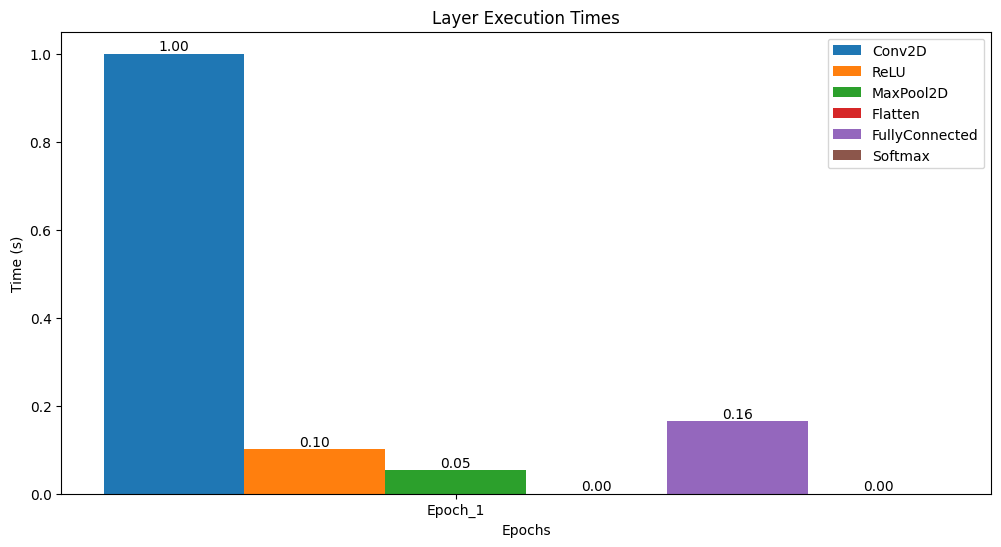

In [36]:
func.plot_details(
    "Data/log/details_log_cuda_10.csv"
)

In [ ]:
# model_2 = SimpleCNN_CUDA()
# train_cuda(
#     model_2,
#     X_train,
#     y_train_onehot,
#     epochs=1,        # train thử 1 epoch
#     learning_rate=0.001,
#     mb_size=64,
#     log_filename="Data/log/training_log_cuda_50000.csv",
#     detail_log_filename="Data/log/details_log_cuda_50000.csv"
# )

Epoch 1/1 - Loss: 0.0359 - Acc: 0.1297 - Time: 6140.95s
    Conv2D: 5915.00s | ReLU: 111.08s | MaxPool: 53.08s | Flatten: 0.62s | FC: 34.72s | Softmax: 0.12s



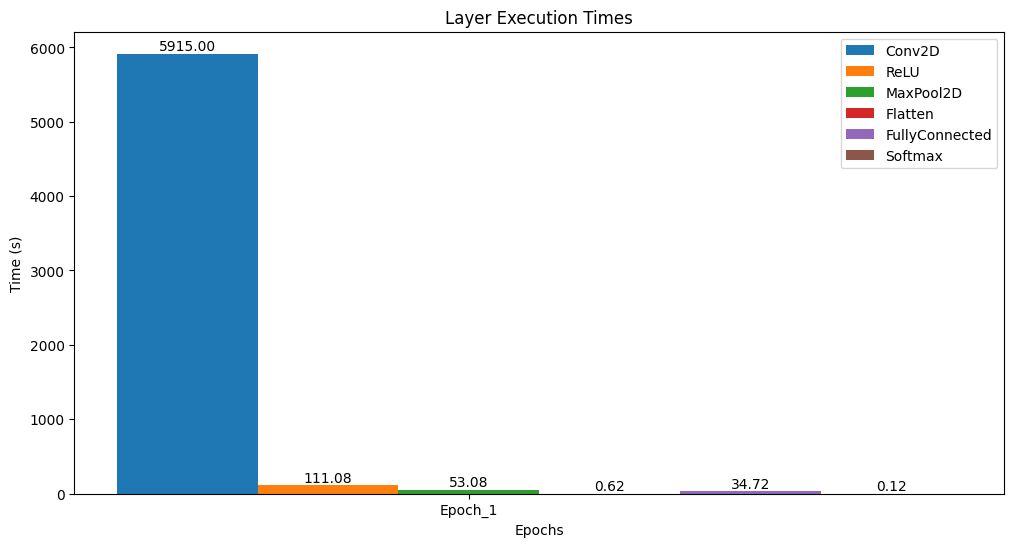

In [ ]:
# func.plot_details(
#     "Data/log/details_log_cuda_50000.csv"
# )

### So sánh 1 epoch giữa Numba và Numpy

In [ ]:
# def plot_compare_details_customized(file1, file2, label1='NumPy', label2='Numba'):
#     def read_data(filename):
#         with open(filename, "r") as file:
#             lines = file.readlines()[1:]
#             data = [line.strip().split(",") for line in lines]

#         conv2d_times = [float(d[2]) for d in data]
#         relu_times = [float(d[3]) for d in data]
#         maxpool_times = [float(d[4]) for d in data]
#         flatten_times = [float(d[5]) for d in data]
#         fc_times = [float(d[6]) for d in data]
#         softmax_times = [float(d[7]) for d in data]
#         return [conv2d_times[0], relu_times[0], maxpool_times[0], flatten_times[0], fc_times[0], softmax_times[0]]

#     # Lấy thời gian từng lớp từ hai file
#     times1 = read_data(file1)
#     times2 = read_data(file2)
#     layer_names = ['Conv2D', 'ReLU', 'MaxPool2D', 'Flatten', 'FC', 'Softmax']

#     x = np.arange(len(layer_names))
#     width = 0.35

#     fig, ax = plt.subplots(figsize=(12, 6))

#     bars1 = ax.bar(x - width/2, times1, width, label=label1, color='skyblue')
#     bars2 = ax.bar(x + width/2, times2, width, label=label2, color='orange')

#     # Ghi giá trị lên từng cột
#     for bar in bars1:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

#     for bar in bars2:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

#     ax.set_xlabel('Layer')
#     ax.set_ylabel('Time (s)')
#     ax.set_title('Execution Time Comparison per Layer in 1st Epoch')
#     ax.set_xticks(x)
#     ax.set_xticklabels(layer_names)
#     ax.legend()
#     ax.grid(True, axis='y', linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()

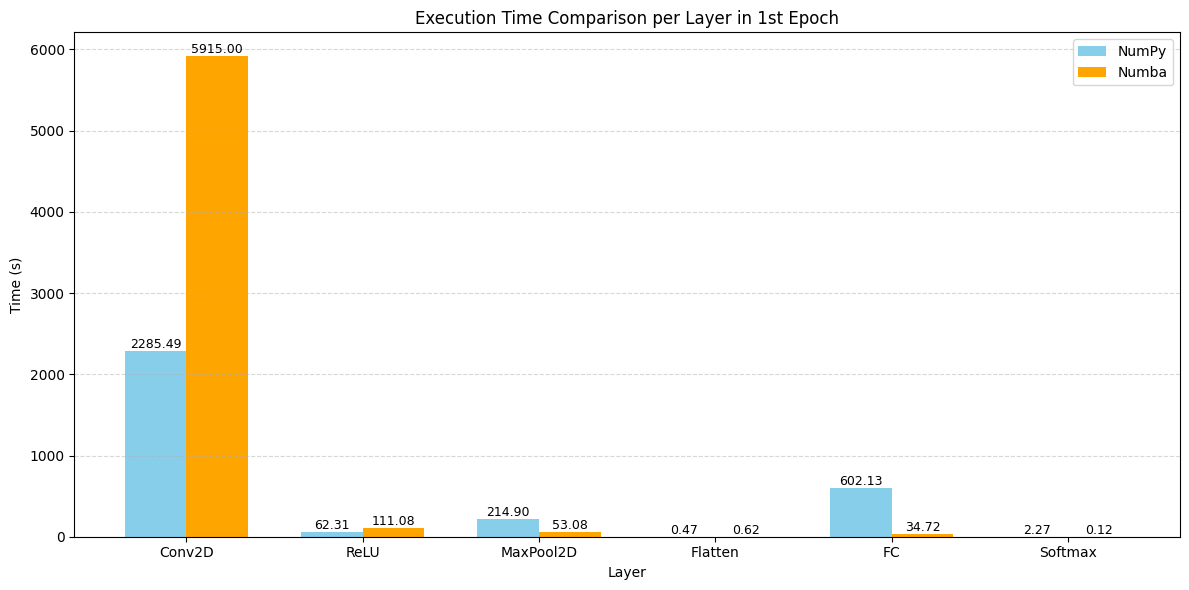

In [ ]:
# plot_compare_details_customized(
#     "Data/log/details_log_numpy_50000.csv",
#     "Data/log/details_log_cuda_50000.csv"
# )